# 🔬 Day 4 Exercise: Breast Cancer Classification

**Time required:** 90–120 minutes 
**Dataset:**  Wisconsin Breast Cancer dataset — 569 tumors, 30 features, classify malignant vs benign 
**Why this dataset:** High-dimensional, no missing values, perfect to show scaling impact

This is also your first **high-stakes prediction problem** — false negatives (missing cancer) cost lives. That's why you'll learn about choosing the right metric for the right problem.

### BLOCK 1: Load and Understand Stakes

In [4]:
# imports and libs
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, ConfusionMatrixDisplay)
import warnings
warnings.filterwarnings('ignore')

# Load Dataset
cancer = load_breast_cancer()
X = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y = pd.Series(cancer.target, name='target')
# Target: 0 = Malignant (cancer), 1 = Benign (no cancer)

print("Dataset shape:", X.shape)
print(f"Classes: {cancer.target_names}")
print(f"Malignant: {(y==0).sum()} ({(y==0).mean():.0%})")
print(f"Benign:    {(y==1).sum()} ({(y==1).mean():.0%})")

print("\nFirst 3 rows, first 5 features:")
print(X.iloc[:3, :5])

Dataset shape: (569, 30)
Classes: ['malignant' 'benign']
Malignant: 212 (37%)
Benign:    357 (63%)

First 3 rows, first 5 features:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness
0        17.99         10.38           122.8     1001.0          0.11840
1        20.57         17.77           132.9     1326.0          0.08474
2        19.69         21.25           130.0     1203.0          0.10960


##### Why Accuracy is not enough here

In [5]:
print("=== THE STAKES ===")
print()
print("False Negative: Model says BENIGN, but it's actually MALIGNANT")
print("  → Patient goes home, cancer goes untreated → potentially fatal")
print()
print("False Positive: Model says MALIGNANT, but it's actually BENIGN")
print("  → Patient gets unnecessary biopsy → stressful but not deadly")
print()
print("For this problem, we MINIMIZE FALSE NEGATIVES.")
print("Metric to focus on: RECALL for the malignant class")
print("  Recall = of all actual cancer cases, how many did we catch?")
print()
print("A model catching 90% of cancers (high recall)")
print("beats one with 95% accuracy that misses 20% of cancers.")

=== THE STAKES ===

False Negative: Model says BENIGN, but it's actually MALIGNANT
  → Patient goes home, cancer goes untreated → potentially fatal

False Positive: Model says MALIGNANT, but it's actually BENIGN
  → Patient gets unnecessary biopsy → stressful but not deadly

For this problem, we MINIMIZE FALSE NEGATIVES.
Metric to focus on: RECALL for the malignant class
  Recall = of all actual cancer cases, how many did we catch?

A model catching 90% of cancers (high recall)
beats one with 95% accuracy that misses 20% of cancers.


### BLOCK 2: The Scaling Experiment

In [6]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

##### SVM Without Scaling

In [7]:
svm_unscaled = SVC(kernel='rbf', random_state=42)
svm_unscaled.fit(X_train, y_train)
pred_unscaled = svm_unscaled.predict(X_test)
acc_unscaled = (pred_unscaled == y_test).mean()

print(f"SVM WITHOUT scaling: {acc_unscaled:.1%} accuracy")
print("\nClassification Report (unscaled SVM):")
print(classification_report(y_test, pred_unscaled,
                             target_names=cancer.target_names))

SVM WITHOUT scaling: 93.0% accuracy

Classification Report (unscaled SVM):
              precision    recall  f1-score   support

   malignant       0.95      0.86      0.90        42
      benign       0.92      0.97      0.95        72

    accuracy                           0.93       114
   macro avg       0.93      0.91      0.92       114
weighted avg       0.93      0.93      0.93       114



##### Apply StandScaler

In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

##### SVM with Scaling

In [12]:
svm_scaled = SVC(kernel='rbf', random_state=42)
svm_scaled.fit(X_train_scaled, y_train)
pred_scaled = svm_scaled.predict(X_test_scaled)
acc_scaled = (pred_scaled == y_test).mean()

print(f"SVM WITH scaling:    {acc_scaled:.1%} accuracy")
print("\nClassification Report (scaled SVM):")
print(classification_report(y_test, pred_scaled,
                             target_names=cancer.target_names))

print(f"\n{'='*45}")
print(f"  Accuracy BEFORE scaling: {acc_unscaled:.1%}")
print(f"  Accuracy AFTER scaling:  {acc_scaled:.1%}")
print(f"  Improvement:             {(acc_scaled-acc_unscaled)*100:.1f} percentage points")
print(f"{'='*45}")
print("\nThis is why scaling is non-negotiable for SVM.")

SVM WITH scaling:    98.2% accuracy

Classification Report (scaled SVM):
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


  Accuracy BEFORE scaling: 93.0%
  Accuracy AFTER scaling:  98.2%
  Improvement:             5.3 percentage points

This is why scaling is non-negotiable for SVM.


##### Visualize: What Scaling

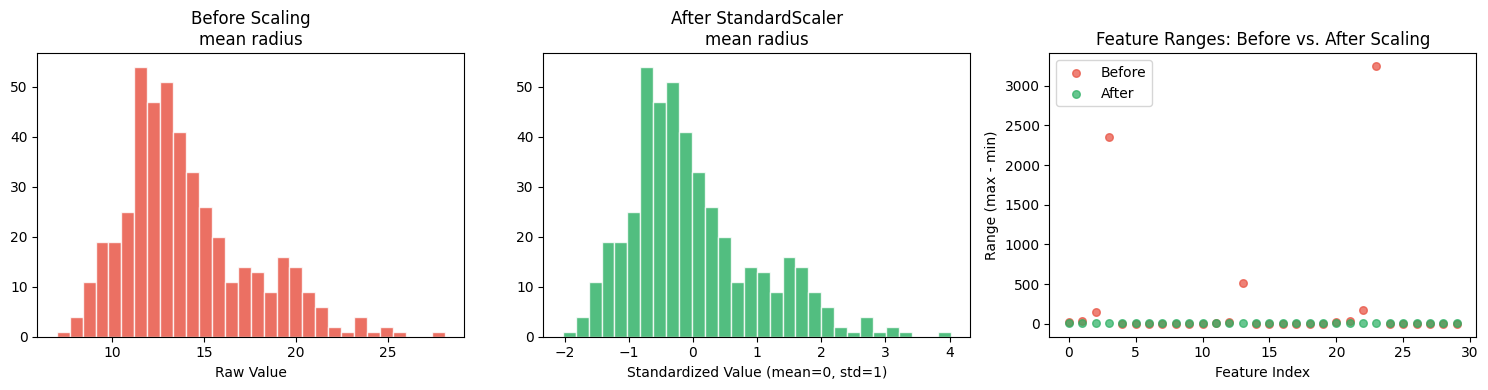

In [14]:
# ── Visualize: What scaling actually does to data ────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

feature_idx = 0   # First feature: mean radius
feature_name = cancer.feature_names[feature_idx]

# Before scaling
axes[0].hist(X_train.iloc[:, feature_idx], bins=30,
             color='#e74c3c', edgecolor='white', alpha=0.8)
axes[0].set_title(f'Before Scaling\n{feature_name}')
axes[0].set_xlabel('Raw Value')

# After StandardScaler
axes[1].hist(X_train_scaled[:, feature_idx], bins=30,
             color='#27ae60', edgecolor='white', alpha=0.8)
axes[1].set_title(f'After StandardScaler\n{feature_name}')
axes[1].set_xlabel('Standardized Value (mean=0, std=1)')

# Compare feature ranges before vs after
raw_ranges = X_train.max() - X_train.min()
scaled_ranges = pd.DataFrame(
    X_train_scaled, columns=cancer.feature_names
).apply(lambda c: c.max() - c.min())

axes[2].scatter(range(len(raw_ranges)), raw_ranges,
                color='#e74c3c', alpha=0.7, label='Before', s=30)
axes[2].scatter(range(len(scaled_ranges)), scaled_ranges,
                color='#27ae60', alpha=0.7, label='After', s=30)
axes[2].set_title('Feature Ranges: Before vs. After Scaling')
axes[2].set_xlabel('Feature Index')
axes[2].set_ylabel('Range (max - min)')
axes[2].legend()

plt.tight_layout()
plt.show()

### BLOCK 4: ROC Curve — A Smarter Way to Evaluate Classifiers

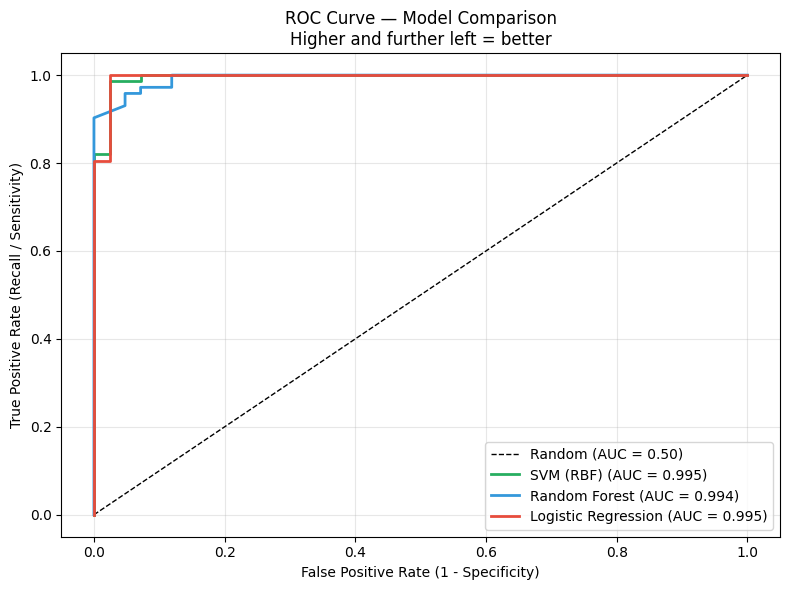

AUC interpretation:
  1.00 = Perfect classifier
  0.90 = Excellent
  0.80 = Good
  0.70 = Fair
  0.50 = Random guessing (worthless)


In [16]:
# ── What is ROC / AUC? ───────────────────────────────────────
# ROC = Receiver Operating Characteristic
# AUC = Area Under the Curve (perfect model = 1.0, random = 0.5)
#
# The ROC curve shows: as you lower the decision threshold,
# how does True Positive Rate trade off with False Positive Rate?
#
# In medicine: you might want to catch 98% of cancers even if it
# means 30% false alarms. Or 95% recall with only 5% false alarms.
# ROC lets you SEE that tradeoff.

# We need probability outputs — use predict_proba
# SVC doesn't give probabilities by default; set probability=True

best_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVC(kernel='rbf', probability=True, random_state=42))
])
rf_pipeline = Pipeline([
    ('model', RandomForestClassifier(n_estimators=100, random_state=42))
])
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.50)', linewidth=1)

for pipe, name, color in [
    (best_pipeline, 'SVM (RBF)', '#27ae60'),
    (rf_pipeline,   'Random Forest', '#3498db'),
    (lr_pipeline,   'Logistic Regression', '#e74c3c'),
]:
    pipe.fit(X_train, y_train)
    probs = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f'{name} (AUC = {auc:.3f})')

ax.set_xlabel('False Positive Rate (1 - Specificity)')
ax.set_ylabel('True Positive Rate (Recall / Sensitivity)')
ax.set_title('ROC Curve — Model Comparison\n'
             'Higher and further left = better')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("AUC interpretation:")
print("  1.00 = Perfect classifier")
print("  0.90 = Excellent")
print("  0.80 = Good")
print("  0.70 = Fair")
print("  0.50 = Random guessing (worthless)")

### BLOCK 5: Tune SVM Hyperparameters

#### SVM has two key hyperparameters:
##### C (regularization): how much you penalize misclassification. High C = tries harder to classify correctly = may overfit
##### gamma (RBF kernel): how far influence of each training point reaches. High gamma = complex boundary

C         Gamma     CV F1-Score
----------------------------------------

Best settings found:
  C = 1.0,  gamma = scale
  CV F1 = 0.9804


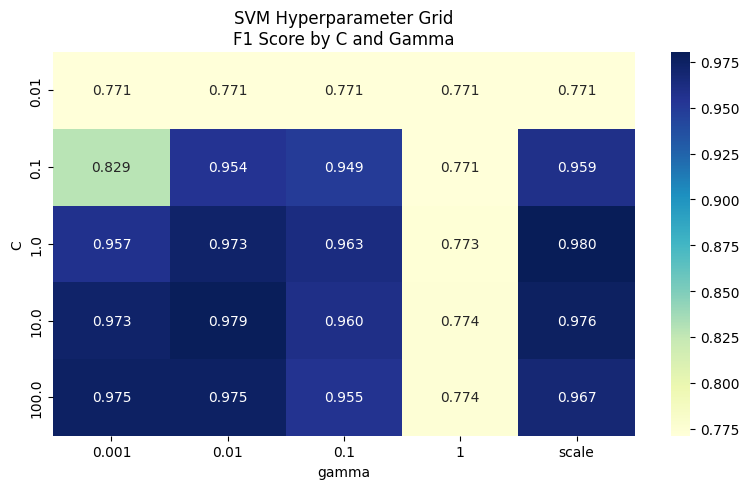

In [17]:
# ── Manual grid search over C and gamma ─────────────────────
C_values     = [0.01, 0.1, 1, 10, 100]
gamma_values = ['scale', 0.001, 0.01, 0.1, 1]

results_grid = []

print("C         Gamma     CV F1-Score")
print("-" * 40)

for C in C_values:
    for gamma in gamma_values:
        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('model', SVC(C=C, gamma=gamma, kernel='rbf', random_state=42))
        ])
        scores = cross_val_score(pipe, X, y, cv=3, scoring='f1', n_jobs=-1)
        results_grid.append({'C': C, 'gamma': str(gamma),
                              'f1': scores.mean()})

results_grid_df = pd.DataFrame(results_grid)
best = results_grid_df.loc[results_grid_df['f1'].idxmax()]
print(f"\nBest settings found:")
print(f"  C = {best['C']},  gamma = {best['gamma']}")
print(f"  CV F1 = {best['f1']:.4f}")

# Pivot table as heatmap
pivot = results_grid_df.pivot(index='C', columns='gamma', values='f1')
plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlGnBu')
plt.title('SVM Hyperparameter Grid\nF1 Score by C and Gamma')
plt.tight_layout()
plt.show()

=== FINAL MODEL PERFORMANCE ===
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



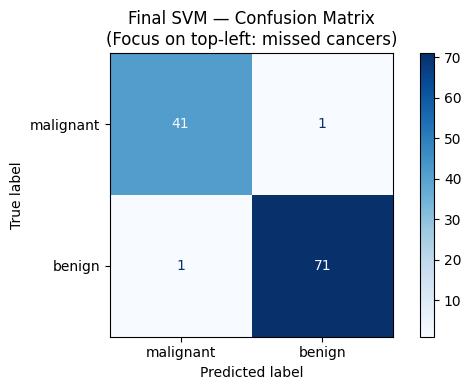


Pipeline (scaler + model) saved as 'cancer_svm_pipeline.pkl'
Loading it on new data will automatically scale and predict. No manual steps.


In [18]:
# ── Final model with best hyperparameters ────────────────────
final_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVC(C=float(best['C']),
                  gamma=best['gamma'] if best['gamma'] != 'scale' else 'scale',
                  kernel='rbf', probability=True, random_state=42))
])
final_pipe.fit(X_train, y_train)
final_pred = final_pipe.predict(X_test)

print("=== FINAL MODEL PERFORMANCE ===")
print(classification_report(y_test, final_pred,
                             target_names=cancer.target_names))

# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, final_pred,
    display_labels=cancer.target_names,
    cmap='Blues', ax=ax
)
ax.set_title('Final SVM — Confusion Matrix\n'
             '(Focus on top-left: missed cancers)')
plt.tight_layout()
plt.show()

# Save pipeline (scaler + model bundled together)
import joblib
joblib.dump(final_pipe, 'cancer_svm_pipeline.pkl')
print("\nPipeline (scaler + model) saved as 'cancer_svm_pipeline.pkl'")
print("Loading it on new data will automatically scale and predict. No manual steps.")